# 01 — Build Optic-Lobe Multi-Compartment HH Network

Build a **multi-compartment** Hodgkin-Huxley network for the right optic lobe
using real FAFB connectivity data (47 K neurons, ~1.1 M edges).

Each neuron uses a shared 2-compartment morphology (soma + dendrite) with
**per-neuron-type** ion-channel parameters and **per-edge** ionotropic
synapse parameters derived from calibrated rule files.

In [1]:
import sys, time, logging
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, '../..')
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

from neuro_framework.models.fafb_mc_network import FAFBMCNetwork

## 1. Build the network

Choose between the **motion-pathway subset** (~26 K neurons, fast) or the
**full right optic lobe** (~47 K neurons).

In [2]:
DATA_DIR = '../../mcHH/data/optic_lobe_right_motion'  # fast subset
# DATA_DIR = '../../mcHH/data/optic_lobe_right'       # full OL (slower)

SWC_PATH = '../../mcHH/data/generic_2comp.swc'
ION_RULES = '../data/fafb_ion_channel_rules.csv'
SYN_RULES = '../data/fafb_synapse_rules.csv'

t0 = time.time()
net = FAFBMCNetwork.from_preprocessed(
    data_dir=DATA_DIR,
    swc_path=SWC_PATH,
    ion_rules_path=ION_RULES,
    syn_rules_path=SYN_RULES,
    ncomp=2,
    min_syn_count=3,
    dt=0.1,
)
print(f'Build: {time.time()-t0:.1f}s')
print(net)

INFO Loaded CSVs in 0.1s
INFO Mapped 308496 edges in 0.2s
INFO Synapse lookup done in 0.9s
INFO FAFBMCNetwork: 26353 neurons (2 comp each), 308496 edges, 4751 photoreceptors [0.9s]


Build: 0.9s
FAFBMCNetwork(n_neurons=26353, n_comp=2, n_edges=308496, n_photo=4751, trainable=1700600)


## 2. Network statistics

Total neuron types: 75
Photoreceptors:     4751
Trainable params:   1,700,600



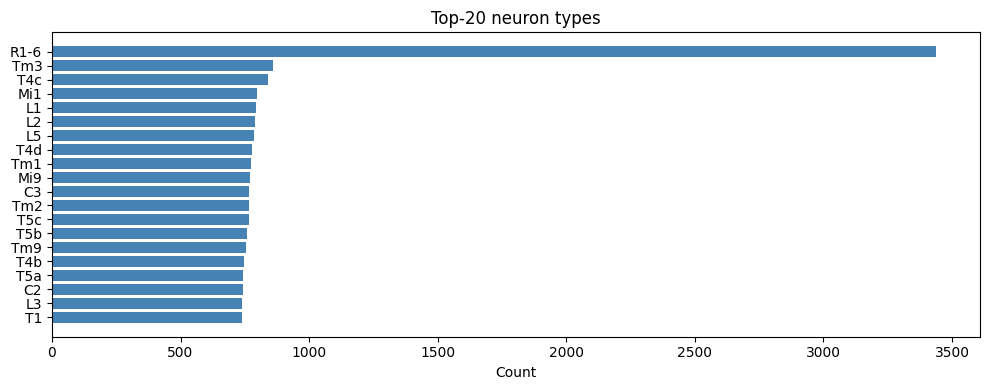

In [3]:
tc = net.type_counts()
print(f'Total neuron types: {len(tc)}')
print(f'Photoreceptors:     {net.input_mask.sum().item()}')
print(f'Trainable params:   {net.n_parameters():,}')
print()

# Show top-20 types
top20 = sorted(tc.items(), key=lambda x: -x[1])[:20]
types, counts = zip(*top20)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(range(len(types)), counts, color='steelblue')
ax.set_yticks(range(len(types)))
ax.set_yticklabels(types)
ax.invert_yaxis()
ax.set_xlabel('Count')
ax.set_title('Top-20 neuron types')
plt.tight_layout()
plt.show()

## 3. Subsystem composition

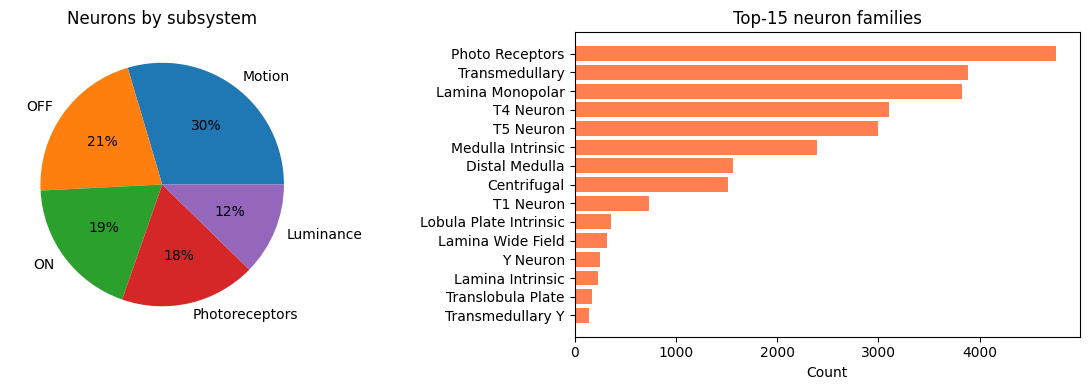

In [4]:
neurons_df = pd.read_csv(DATA_DIR + '/neurons.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ss = neurons_df['subsystem'].value_counts()
axes[0].pie(ss.values, labels=ss.index, autopct='%1.0f%%')
axes[0].set_title('Neurons by subsystem')

fam = neurons_df['family'].value_counts().head(15)
axes[1].barh(range(len(fam)), fam.values, color='coral')
axes[1].set_yticks(range(len(fam)))
axes[1].set_yticklabels(fam.index)
axes[1].invert_yaxis()
axes[1].set_xlabel('Count')
axes[1].set_title('Top-15 neuron families')

plt.tight_layout()
plt.show()

## 4. Connectivity matrix (type → type)

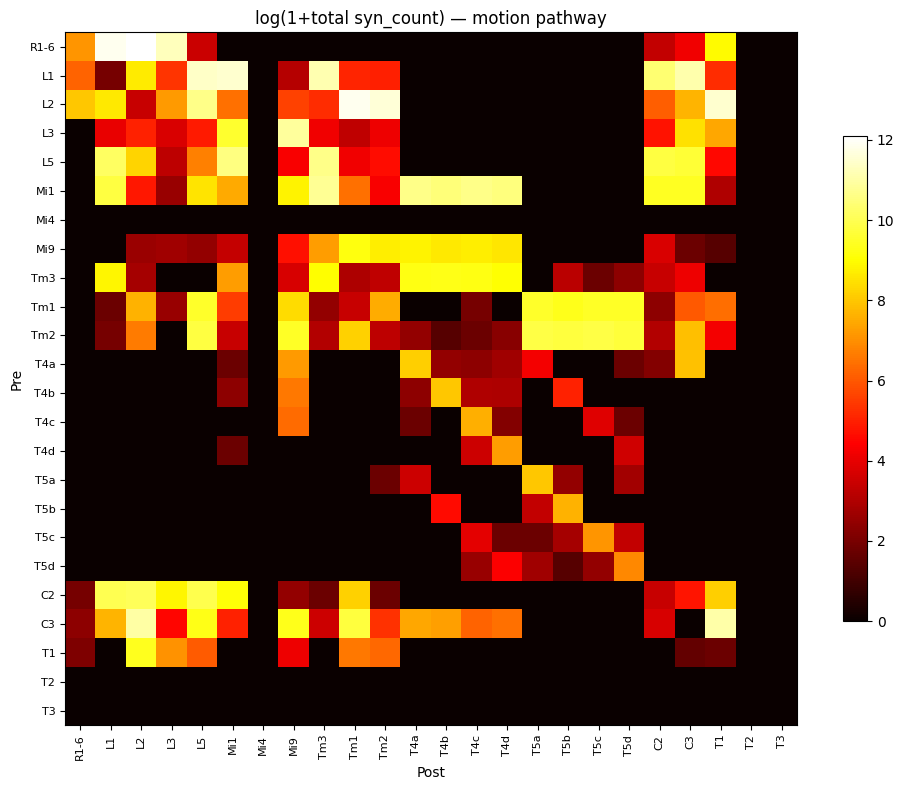

In [5]:
conn_df = pd.read_csv(DATA_DIR + '/connections.csv')
conn_df = conn_df[conn_df['syn_count'] >= 3]

pathway_types = ['R1-6', 'L1', 'L2', 'L3', 'L5', 'Mi1', 'Mi4', 'Mi9',
                 'Tm3', 'Tm1', 'Tm2', 'T4a', 'T4b', 'T4c', 'T4d',
                 'T5a', 'T5b', 'T5c', 'T5d', 'C2', 'C3', 'T1', 'T2', 'T3']

sub = conn_df[conn_df['pre_type'].isin(pathway_types) &
              conn_df['post_type'].isin(pathway_types)]
mat = sub.groupby(['pre_type', 'post_type'])['syn_count'].sum().unstack(fill_value=0)
mat = mat.reindex(index=pathway_types, columns=pathway_types, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(np.log1p(mat.values), cmap='hot', aspect='auto')
ax.set_xticks(range(len(pathway_types)))
ax.set_xticklabels(pathway_types, rotation=90, fontsize=8)
ax.set_yticks(range(len(pathway_types)))
ax.set_yticklabels(pathway_types, fontsize=8)
ax.set_xlabel('Post'); ax.set_ylabel('Pre')
ax.set_title('log(1+total syn_count) — motion pathway')
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

## 5. Per-type HH parameter summary

In [6]:
show_types = ['R1-6', 'L1', 'L3', 'L5', 'Mi1', 'Mi9', 'Tm3', 'T4a']

print(f'{"Type":>8s}  {"n":>5s}  {"gNa":>8s}  {"gK":>8s}  {"gL":>8s}  '
      f'{"E_Na":>6s}  {"E_K":>6s}  {"E_L":>6s}')
for ct in show_types:
    idx = net.get_indices_by_type(ct)
    if not idx:
        continue
    i = idx[0]
    print(f'{ct:>8s}  {len(idx):5d}  '
          f'{net.g_Na[i].item():8.3f}  {net.g_K[i].item():8.3f}  '
          f'{net.g_L[i].item():8.3f}  '
          f'{net.E_Na[i].item():6.1f}  {net.E_K[i].item():6.1f}  '
          f'{net.E_L[i].item():6.1f}')

    Type      n       gNa        gK        gL    E_Na     E_K     E_L
    R1-6   3437     2.951     2.295     2.870    49.5   -77.3   -45.0
      L1    793     9.939     2.454     1.770    48.1   -77.1   -40.7
      L3    738     3.895     2.182     1.796    49.2   -77.0   -52.1
      L5    785     9.805     1.412     1.424    46.6   -76.5   -43.2
     Mi1    796     7.377     1.898     2.055    49.3   -76.8   -45.3
     Mi9    770     1.101     1.360     1.533    48.9   -76.5   -47.8
     Tm3    858     8.054     1.168     2.132    51.6   -76.9   -47.2
     T4a    737     2.809     1.801     2.230    50.4   -77.5   -51.1


## 6. Quick smoke test — 2-step forward pass

In [7]:
n_photo = net.input_mask.sum().item()
x = torch.zeros(1, 2, n_photo)
x[:, 1, :] = 30.0

t0 = time.time()
with torch.no_grad():
    out = net(x)
print(f'2-step forward: {time.time()-t0:.3f}s')
print(f'V range: [{out.min():.1f}, {out.max():.1f}]')
print('NaN check:', 'PASS' if not torch.isnan(out).any() else 'FAIL')

/Users/lengyuner/anaconda3/envs/comp_neuro/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Sim 26353N/308496E: 100%|██████████| 2/2 [00:00<00:00, 30.91step/s]

2-step forward: 0.167s
V range: [-57.6, -41.7]
NaN check: PASS
